In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from utilsforecast.plotting import plot_series
from utilsforecast.losses import mae, rmse, smape, mase
from utilsforecast.evaluation import evaluate

from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from functools import partial
from sklearn.preprocessing import StandardScaler

import warnings
#предупреждение  печати statsmodels (verbose)
warnings.filterwarnings("ignore", category=FutureWarning, module="statsmodels")

In [58]:
df = pd.read_csv('climate_EDA.csv', parse_dates=["date"], index_col = "date")
ts = ['energy_consumption']
exog_cols = ['avg_temperature', 'humidity','urban_population', 'energy_price']
base_cols = ['unique_id', 'ds', 'y']

y = df.resample('W').agg({
    'energy_consumption': 'mean',
    'avg_temperature': 'mean',
    'urban_population': 'mean',
    'humidity': 'mean',
    'energy_price': 'sum',
})

y = y.iloc[1:-2]

date_index = y.index

panel_list = [
    pd.DataFrame({
        'ds': y.index,
        'y': y[t].values,
        'unique_id': t,
        # Добавляем внешние переменные из y:
        'avg_temperature': y['avg_temperature'].values,
        'urban_population': y['urban_population'].values,
        'humidity': y['humidity'].values,
        'energy_price': y['energy_price'].values
    })
    for t in ts
]

panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols + exog_cols]

FH = int(0.42 * y.shape[0])
df_test = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

FREQ = y.index.freq
SEASON = 52

# Анализ аномалий

**Поиск аномалий с помощью вероятностного предсказания**

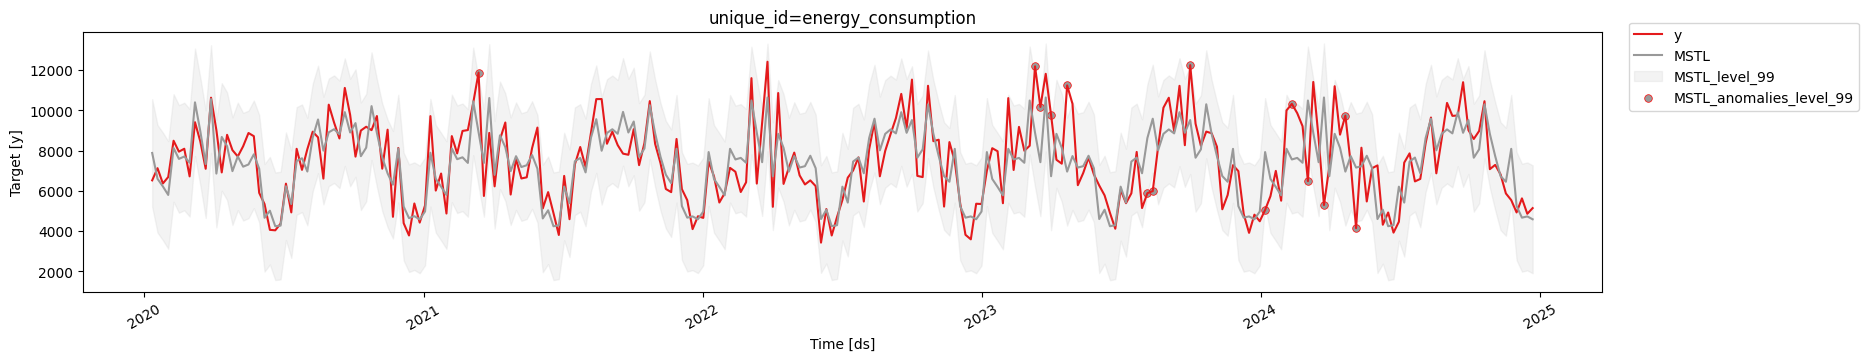

In [59]:
from statsforecast.models import MSTL
from statsforecast import StatsForecast

levels = [99]
models = [MSTL(season_length=[SEASON], alias='MSTL')]
alias = [x.alias for x in models]

sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst = sf.forecast(df=df_train, h=FH, level=levels, fitted=True)

insample_forecasts = sf.forecast_fitted_values().drop(columns=['y'])

res_df = panel_df.merge(pd.concat([insample_forecasts,fcst],), on=['unique_id', 'ds'], how='left')
res_df = res_df.drop(columns=['humidity', 'urban_population',	'energy_price', 'avg_temperature'],)

plot_series(forecasts_df=res_df, level=levels, plot_anomalies=True, palette='Set1')

In [60]:
res_df['residual'] = res_df['y'] - res_df['MSTL']
anomalies_mstl = res_df[~res_df['y'].between(res_df['MSTL-lo-99'], res_df['MSTL-hi-99'])][['unique_id', 'ds', 'y']].copy()
anomalies_mstl['MSTL_anomaly'] = 1
anomalies_mstl

,unique_id,ds,y,MSTL_anomaly
61,energy_consumption,2021-03-14,11883.411429,1
165,energy_consumption,2023-03-12,12194.462857,1
166,energy_consumption,2023-03-19,10175.352857,1
168,energy_consumption,2023-04-02,9767.761429,1
171,energy_consumption,2023-04-23,11246.861429,1
186,energy_consumption,2023-08-06,5887.514286,1
187,energy_consumption,2023-08-13,5990.728571,1
194,energy_consumption,2023-10-01,12253.758571,1
208,energy_consumption,2024-01-07,5053.248571,1
213,energy_consumption,2024-02-11,10324.344286,1


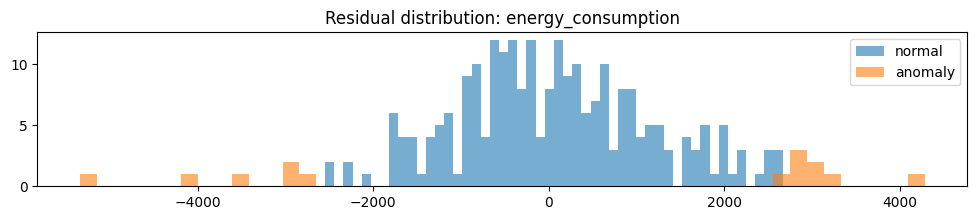

In [61]:
res_df['is_anomaly'] = ~res_df['y'].between(res_df['MSTL-lo-99'], res_df['MSTL-hi-99'])

res_df['residual'] = res_df['y'] - res_df['MSTL']
for uid, df_uid in res_df.groupby('unique_id'):
    plt.figure(figsize = (12,2))
    # нормальные точки
    plt.hist(df_uid[df_uid['is_anomaly']==0]['residual'], bins=50, alpha=0.6, label='normal')
    # аномалии
    plt.hist(df_uid[df_uid['is_anomaly']==1]['residual'], bins=50, alpha=0.6, label='anomaly')
    plt.title(f"Residual distribution: {uid}")
    plt.legend()
    plt.show()

**Isolation Forest**

Даты аномалий для энергии: ['2023-03-26', '2024-03-31', '2024-06-23']


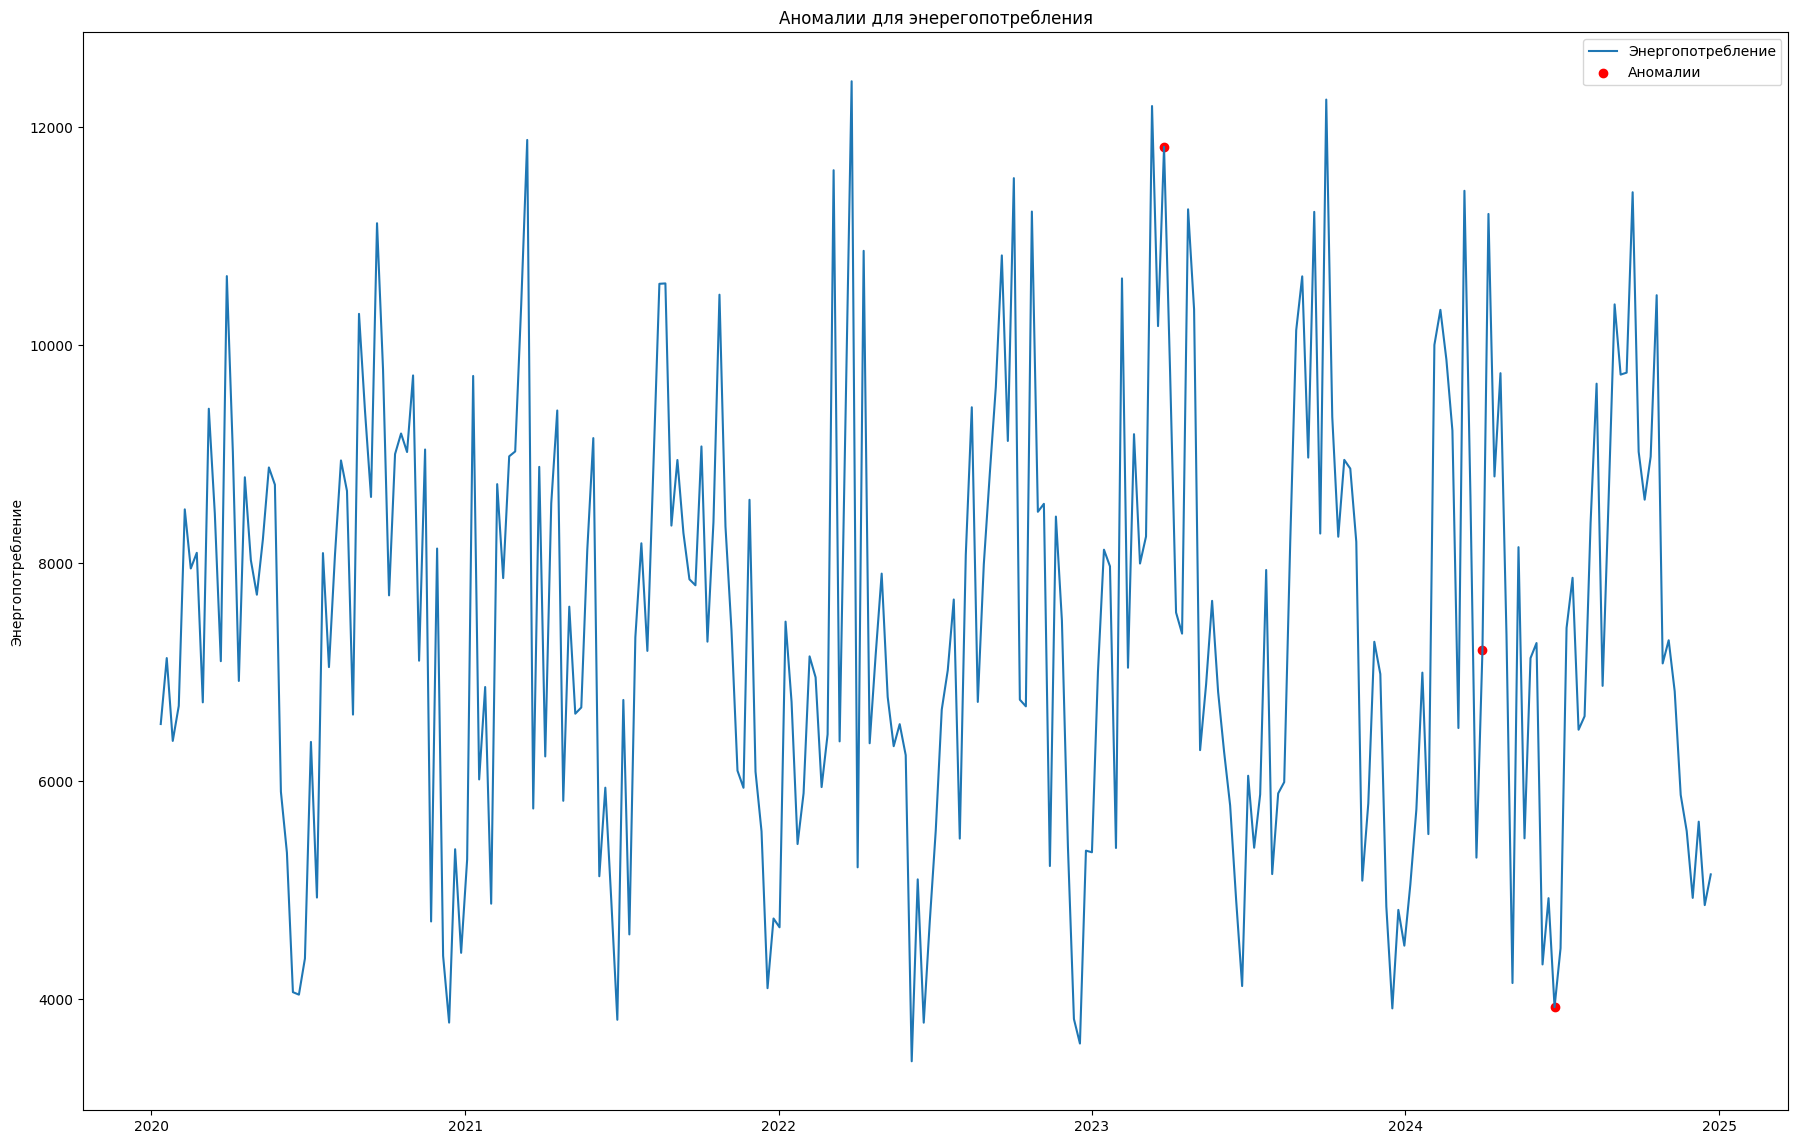

In [62]:
from sklearn.ensemble import IsolationForest

def detect_isolation_forest_anomlies(df):
  for lag in [7, 26, 52]:
    df[f'lag_{lag}'] = df['y'].shift(lag)
    df[f'lag_{lag}'] = df['y'].shift(lag)
  scaler = StandardScaler()
  df_scaled = scaler.fit_transform(df)
  iso_forest = IsolationForest(n_estimators = 100, contamination=0.01, random_state=42)
  iso_predict = iso_forest.fit_predict(df_scaled)
  anomalies = df.index[iso_predict == -1]
  return anomalies

df_iso_en = panel_df[['ds', 'y']].copy().set_index('ds')

anomalies_if = detect_isolation_forest_anomlies(df_iso_en)
print(f'Даты аномалий для энергии: {list(anomalies_if.strftime("%Y-%m-%d"))}')

fig, axes = plt.subplots(1, 1, figsize = (22, 14))

axes.plot(df_iso_en.index, df_iso_en['y'], label='Энергопотребление')
axes.scatter(anomalies_if, df_iso_en.loc[anomalies_if, 'y'], label = 'Аномалии', color = 'red')
axes.set_title('Аномалии для энерегопотребления')
axes.set_ylabel('Энергопотребление')
axes.legend()

**IQR**

In [63]:
def detect_iqr_anomalies(df):
  Q1 = df.quantile(0.25)
  Q3 = df.quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df_iqr = (df < lower_bound) | (df > upper_bound)
  return df_iqr

df_en = panel_df[['ds', 'y']].copy().set_index('ds')
result_iqr = detect_iqr_anomalies(df_en)
anomalies_iqr = result_iqr[result_iqr['y']==True]
print(f"Энергопотребление аномалии: {anomalies_iqr['y'].sum()}")

Энергопотребление аномалии: 0


In [64]:
#Сравнение обнаруженных аномалий
dates_mstl = [d.strftime('%Y-%m-%d') for d in list(anomalies_mstl['ds'])]
dates_iqr = [d.strftime('%Y-%m-%d') for d in list(anomalies_iqr.index)]
print(f'Даты аномалий вероятностного прогнозирования: {dates_mstl}')
print(f'Даты аномалий IQR: {dates_iqr}')
print(f'Даты аномалий IsolationForest: {list(anomalies_if.strftime("%Y-%m-%d"))}')

Даты аномалий вероятностного прогнозирования: ['2021-03-14', '2023-03-12', '2023-03-19', '2023-04-02', '2023-04-23', '2023-08-06', '2023-08-13', '2023-10-01', '2024-01-07', '2024-02-11', '2024-03-03', '2024-03-24', '2024-04-21', '2024-05-05']
Даты аномалий IQR: []
Даты аномалий IsolationForest: ['2023-03-26', '2024-03-31', '2024-06-23']


Вероятностное предсказание и IsolationForest оба определили аномалии в недели '2023-04-23', '2024-10-01'.



# ML Предсказание

In [65]:
from sklearn.linear_model import Ridge, LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

In [66]:
date_features = ['week']
models={
        'lasso': Lasso(),
        'lin_reg': LinearRegression(),
        'ridge': Ridge(alpha=0.10),
        'rf': RandomForestRegressor(n_estimators=400, max_depth=6, random_state=42),
        'lgbm':LGBMRegressor(n_estimators=100, verbosity=-1),
}

LEVELS = [75, 90, 95]

fcst = MLForecast(
    models = models,
    freq=FREQ,
    date_features = date_features,
    target_transforms=[Differences([52])],
)
fcst.fit(df_train, )
fcst_sf = fcst.predict(h=FH, )

eval_mf = df_test[['unique_id', 'ds', 'y']].merge(
    fcst_sf,
    on=['unique_id', 'ds'],
    how='inner'
)

metrics = [mae, rmse, smape]
season_mase = partial(mase, seasonality=SEASON)
metrics +=[season_mase]
ml_metrics = evaluate(
    df=eval_mf,
    metrics=metrics,
    train_df=df_train
).set_index('metric')

ml_metrics

,unique_id,lasso,lin_reg,ridge,rf,lgbm
metric,,,,,,
mae,energy_consumption,1601.272106,1601.287394,1601.287286,2071.775135,1698.274581
rmse,energy_consumption,2128.696289,2128.722075,2128.721893,2717.074055,2253.682622
smape,energy_consumption,0.110353,0.110354,0.110354,0.144316,0.117148
mase,energy_consumption,1.094799,1.094809,1.094809,1.416484,1.161120


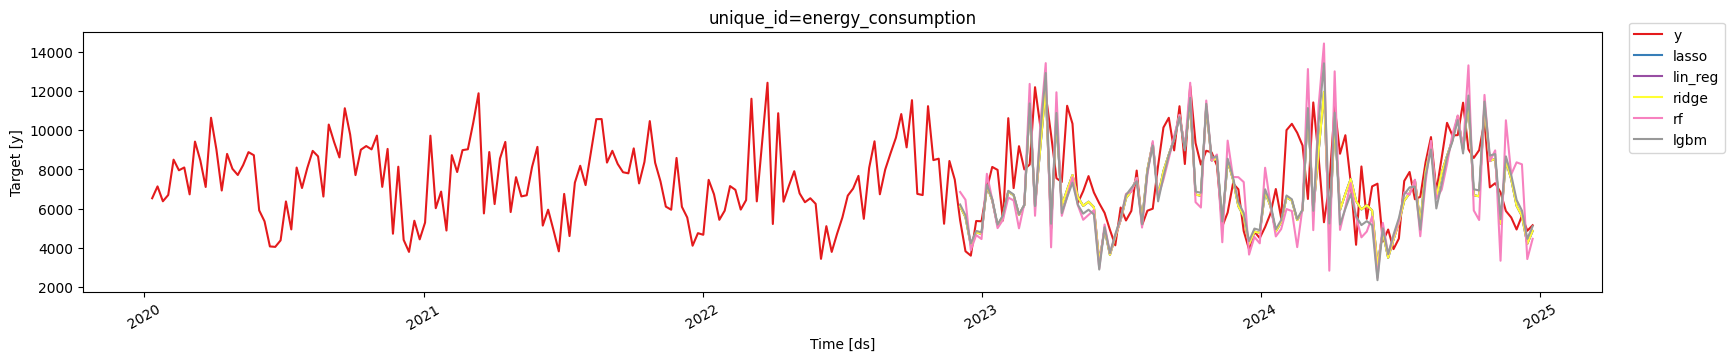

In [67]:
plot_series(
            df_train,
            forecasts_df=eval_mf,
            palette='Set1',
        )

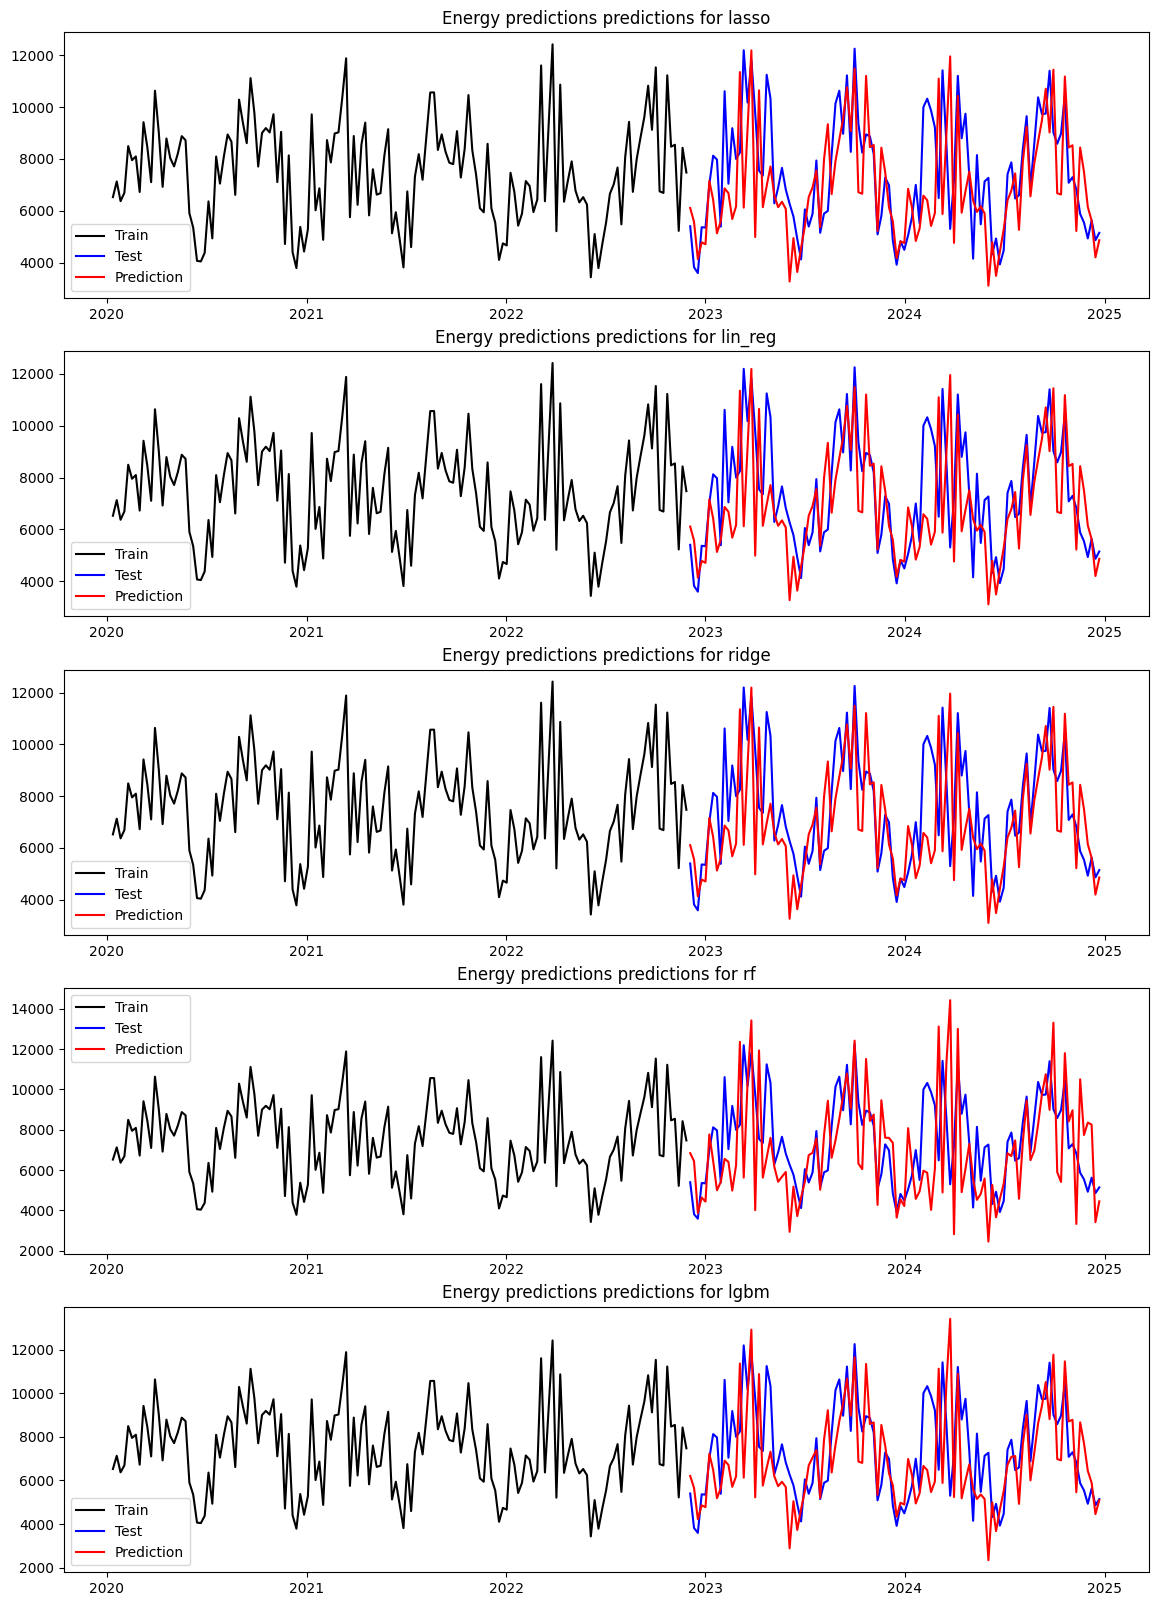

In [68]:
models = ['lasso',	'lin_reg',	'ridge',	'rf', 'lgbm']
fig, axes = plt.subplots(len(models), 1, figsize=(14, 4 * len(models)))
#test_len = len(df_test)
test_len = 108
df_predict = eval_mf.head(test_len)
for i in range(len(models)):
  curr_model = models[i]
  axes[i].plot(df_train['ds'], df_train['y'], color = 'black', label='Train')
  axes[i].plot(df_test['ds'], df_test['y'], color = 'blue', label='Test')
  axes[i].plot(df_predict['ds'], df_predict[curr_model], color = 'red', label='Prediction')
  axes[i].set_title(f"Energy predictions predictions for {curr_model}")
  axes[i].legend()

# DL Модели

In [69]:
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, NHITS, DLinear, Informer, TFT, PatchTST, MLP
from neuralforecast.auto import AutoNHITS

In [ ]:
test_size = SEASON
horizon = SEASON
val_size  = test_size//2
log_path = ''

models = [
        LSTM(h=horizon, input_size = test_size, max_steps=50, scaler_type='standard', random_seed=42),
        NHITS(h=horizon, input_size = test_size, max_steps=50, n_freq_downsample=[1, 1, 1],),
        PatchTST(h=horizon, input_size = test_size, max_steps=50,),
]

nf = NeuralForecast(models=models, freq=FREQ)
nf.fit(df=df_train, val_size=0)
y_hat = nf.predict(df_train)

eval_dl = df_test[['unique_id', 'ds', 'y']].merge(
    y_hat,
    on=['unique_id', 'ds'],
    how='inner'
)

dl_metrics = evaluate(
    df=eval_dl,
    metrics=metrics,
    train_df=df_train
).set_index('metric')

dl_metrics

Seed set to 42
Seed set to 1
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | hist_encoder | LSTM          | 199 K  | train
4 | mlp_decoder  | MLP           | 16.6 K | train
-------------------------------------------------------
215 K     Trainable params
0         Non-trainable params
215 K     Total params
0.863     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


c:\Users\Acer\Desktop\github\melekhin-time-series\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Acer\Desktop\github\melekhin-time-series\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\Acer\Desktop\github\melekhin-time-series\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\Acer\Desktop\github\melekhin-time-series\.venv\Lib\site-packages\pytorch_lightning\loop

Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 10.31it/s, v_num=39, train_loss_step=0.514, train_loss_epoch=0.514]

`Trainer.fit` stopped: `max_steps=100` reached.


Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 10.00it/s, v_num=39, train_loss_step=0.514, train_loss_epoch=0.514]

...

GPU available: False, used: False
TPU available: False, using: 0 TPU cores



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 142.84it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 166.63it/s]


,unique_id,LSTM,NHITS,PatchTST
metric,,,,
mae,energy_consumption,1518.088874,1485.438142,1397.482243
rmse,energy_consumption,1921.834624,1840.705480,1729.919782
smape,energy_consumption,0.102762,0.102853,0.093290
mase,energy_consumption,1.037926,1.015602,0.955466


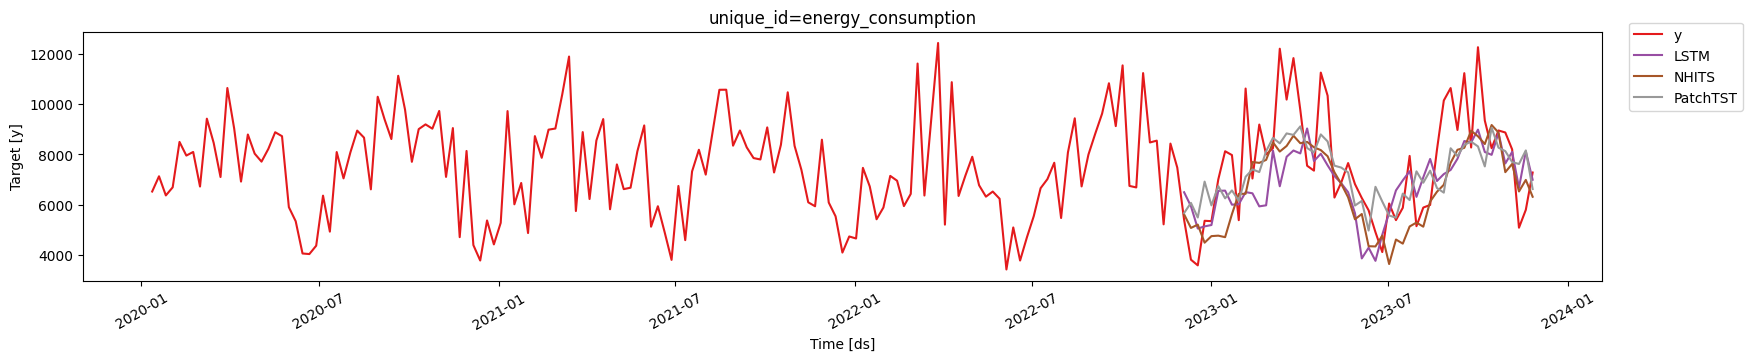

In [72]:
plot_series(
            df_train,
            forecasts_df=eval_dl,
            palette='Set1',
        )

In [73]:
avg_by_series_ml = ml_metrics.groupby(['unique_id', 'metric']).mean(numeric_only=True)
avg_by_series_ml.style.background_gradient(cmap='RdYlGn_r', axis=1).format(precision=2)

In [74]:
avg_by_series_dl = dl_metrics.groupby(['unique_id', 'metric']).mean(numeric_only=True)
avg_by_series_dl.style.background_gradient(cmap='RdYlGn_r', axis=1).format(precision=2)